# Machine Learning Exercise 3: Bias and Variance

**Bias** refers to the error introduced by approximating a complex real-world problem with a simplified model, while **variance** refers to the model's sensitivity to fluctuations in the training data. A linear regression model has high bias and low variance; it makes strong assumptions about the data (linearity) but is stable across different datasets. If these strong assumptions are not correct, there will be places where it systematically overestimates or underestimates. In contrast, a decision tree model has low bias and high variance;it can capture complex patterns but is prone to overfitting, especially if deep and unpruned. This means that it can start to memorize the training data rather than capturing patterns that generalize.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

## 1. Fit a linear regression model to the housing data, using sqft_living to predict price. Check the mean squared error on the training data and the test data.

In [2]:
# Read dataset
house_df = pd.read_csv('data/kc_house_data.csv')
house_df.shape

(21613, 21)

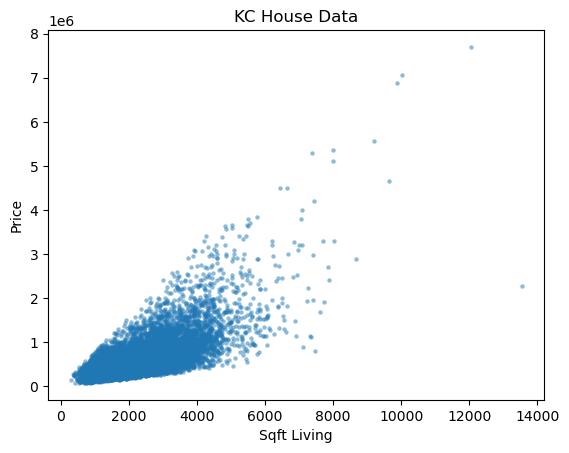

In [3]:
# Plot price per sqft living
plt.scatter(
    house_df['sqft_living'],
    house_df['price'],
    s=10,
    alpha=0.5,
    linewidths=0
)
plt.title('KC House Data')
plt.xlabel('Sqft Living')
plt.ylabel('Price');

In [4]:
# Set constants
TARGET = 'price'
RANDOM_STATE = 42

In [5]:
# Creat training and testing data
features = ['sqft_living']

X = house_df[features]
y = house_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state = RANDOM_STATE
)

In [6]:
# Create linear regression model
model = LinearRegression().fit(X_train, y_train)

In [7]:
# Predict with test data
y_pred = model.predict(X_test)

In [8]:
# Mean squared error
mean_squared_error(y_test, y_pred)

74509993356.49603

In [9]:
# Create dataframe for plotting predictions
predictions_df = pd.DataFrame()

In [10]:
# Add linear regression predictions to dataframe
predictions_df['lr_pred'] = y_pred

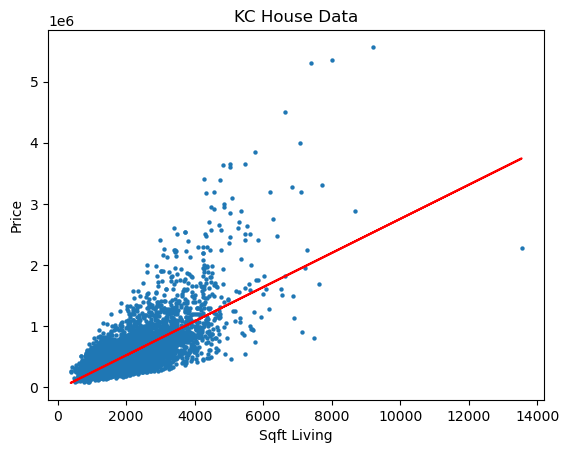

In [11]:
# Plot linear regression predictions
plt.scatter(
    X_test,
    y_test,
    linewidths=0,
    s=10
)
plt.plot(
    X_test,
    predictions_df['lr_pred'],
    color='red'
)
plt.title('KC House Data')
plt.xlabel('Sqft Living')
plt.ylabel('Price');

## 2. Repeat this but with a [DecisionTreeRegresor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html).
Again check the mean squared error on the training data and the test data. How does what you see differ from the linear regression model?

In [12]:
# Create decision tree regression model
model = DecisionTreeRegressor().fit(X_train, y_train)

In [13]:
# Predict with test data
y_pred = model.predict(X_test)

In [14]:
# Mean squared error
mean_squared_error(y_test, y_pred)

79044952597.92511

In [15]:
# Add decision tree predictions to dataframe
predictions_df['dt_pred'] = y_pred

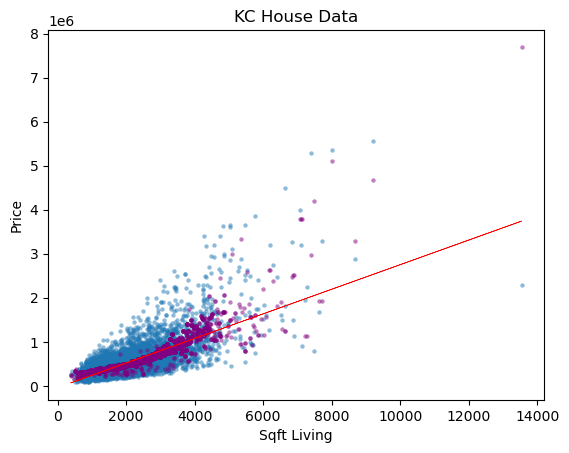

In [16]:
# Plot decision tree predictions vs linear regression
plt.scatter(
    X_test,
    y_test,
    linewidths=0,
    s=10,
    alpha=0.5
)
plt.plot(
    X_test,
    predictions_df['lr_pred'],
    color='red',
    linewidth=0.5
)
plt.scatter(
    X_test,
    predictions_df['dt_pred'],
    linewidths=0,
    s=10,
    alpha=0.5,
    color='purple'
)
plt.title('KC House Data')
plt.xlabel('Sqft Living')
plt.ylabel('Price');

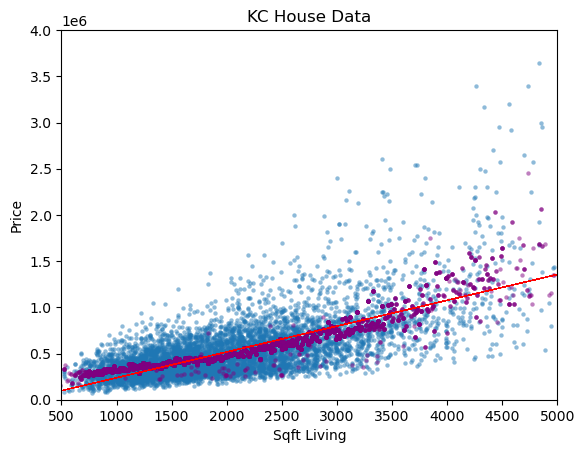

In [17]:
# Set value limits
plt.scatter(
    X_test,
    y_test,
    linewidths=0,
    s=10,
    alpha=0.5
)
plt.plot(
    X_test,
    predictions_df['lr_pred'],
    color='red',
    linewidth=0.5
)
plt.scatter(
    X_test,
    predictions_df['dt_pred'],
    linewidths=0,
    s=10,
    alpha=0.5,
    color='purple'
)
plt.xlim(500, 5000)
plt.ylim(0, 4000000)
plt.title('KC House Data')
plt.xlabel('Sqft Living')
plt.ylabel('Price');

#### One way of avoiding overfitting is by restricting the flexibility of the model. We can do this with a decision tree by restricting the number of splits that it can perform. 

## 3. Fit a DecisionTreeRegressor where you restrict the max_depth to 5. Again check the mean squared error on the training data and the test data. What do you notice now?

In [18]:
# Re-create decision tree model
model = DecisionTreeRegressor(max_depth=5).fit(X_train, y_train)

In [19]:
# Predict with new model
y_pred = model.predict(X_test)

In [20]:
mean_squared_error(y_test, y_pred)

73264250436.88351

In [21]:
predictions_df['dt_pred'] = y_pred

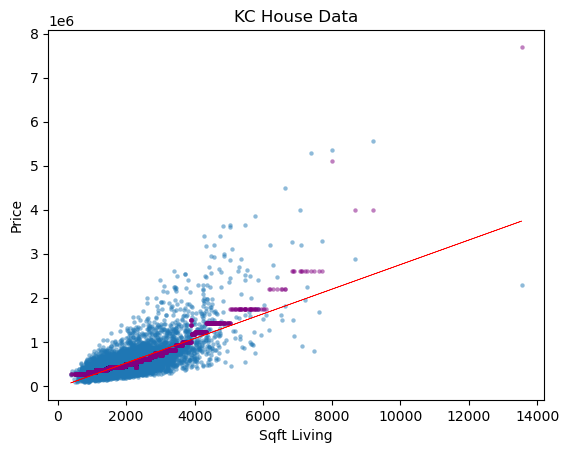

In [22]:
# Plot decision tree predictions vs linear regression
plt.scatter(
    X_test,
    y_test,
    linewidths=0,
    s=10,
    alpha=0.5
)
plt.plot(
    X_test,
    predictions_df['lr_pred'],
    color='red',
    linewidth=0.5
)
plt.scatter(
    X_test,
    predictions_df['dt_pred'],
    linewidths=0,
    s=10,
    alpha=0.5,
    color='purple'
)
plt.title('KC House Data')
plt.xlabel('Sqft Living')
plt.ylabel('Price');

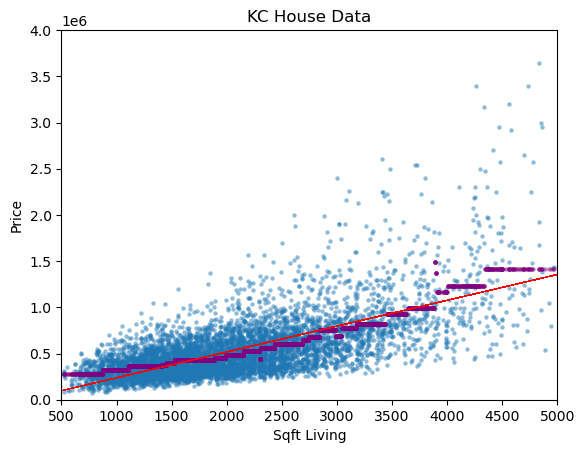

In [23]:
# Set value limits
plt.scatter(
    X_test,
    y_test,
    linewidths=0,
    s=10,
    alpha=0.5
)
plt.plot(
    X_test,
    predictions_df['lr_pred'],
    color='red',
    linewidth=0.5
)
plt.scatter(
    X_test,
    predictions_df['dt_pred'],
    linewidths=0,
    s=10,
    alpha=0.5,
    color='purple'
)
plt.xlim(500, 5000)
plt.ylim(0, 4000000)
plt.title('KC House Data')
plt.xlabel('Sqft Living')
plt.ylabel('Price');

#### When working with machine learning models, we often have to balance bias and variance. This is called the [bias-variance tradeoff](https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff). One method of this is through [regularization](https://www.ibm.com/think/topics/regularization), where we restrict the complexity of the model, adding some bias but reducing the variance, which can lead to a lower mean squared error on the test set.

#### Lasso and ridge regression do this by adding a penalty term based on the size of the coefficients. Smaller coefficients means that the model has less flexibility. The neat thing about these types of models is that they determine how to allocate the coefficients automatically as part of the model fitting process, so we can start with a large set of potential predictors and allow the model fitting to determine which ones to focus on.

#### For the next part of the exercise, we'll see how we can add complexity to our model but control the complexity through regularization.

## 4. So far, we've only been predicting based off of the square footage of living space.
Fit a new linear regression model using all variables besides id, date, price, and zipcode. How well does this model perform on the test set compared to the model with just square footage of living space?

In [24]:
# Create training and testing data with all features
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

X = house_df[features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE
)

In [25]:
# Create linear regression model with new training
model = LinearRegression().fit(X_train, y_train)

In [26]:
# Predict price with new test data
y_pred = model.predict(X_test)

In [27]:
# Mean squared error
mean_squared_error(y_test, y_pred)

44093475276.57418

## 5. Try fitting a lasso and ridge model.
Becuase lasso and ridge have penalty terms based on the size of the coefficients, and the size of the coefficients depends on the scale of the variable, you'll want to scale the features first so that they are on comparable scales. Create a [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) object where the first step is applying a [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) and the second step is either a lasso or ridge model. Because these models have a hyperparameter controlling regularization strength, you'll want to use the [LassoCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html) and [RidgeCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html) models, which will select values for the regularization strength using cross-validation.

In [28]:
# Create pipeline for lasso model
pipe = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('lasso', LassoCV())
    ]
)

In [29]:
# Fit data
pipe.fit(X_train, y_train)

# Predict prices
y_pred = pipe.predict(X_test)

# Mean squared error
mean_squared_error(y_test, y_pred)

44128929521.62934

In [30]:
# Create pipeline for ridge model
pipe = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV())
    ]
)

In [31]:
# Fit data
pipe.fit(X_train, y_train)

# Predict prices
y_pred = pipe.predict(X_test)

# Mean squared error
mean_squared_error(y_test, y_pred)

44094763932.52733

#### You likely didn't see much difference between the regular linear regression model and the lasso or ridge model. Let's see what happens if we add more complexity through feature interactions. We can capture more complex relationships between the predictor variables and the target variable by multiplying the predictors together before fitting the model. For example, the interaction between sqft_living and bedrooms will let the model capture if the impact of square footage depends on the number of bedrooms.

## 6. Add [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) to your pipeline after the standard scaler.
Try using degree 2 features. How does this change the performance of the regular linear regression model, the lasso model, and the ridge model? 

In [32]:
# Create pipeline for linear model
linear_pipe = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ]
)

# Fit data
linear_pipe.fit(X_train, y_train)

# Predict prices
y_pred = linear_pipe.predict(X_test)

# Mean squared error
mean_squared_error(y_test, y_pred)

30926927395.20743

In [33]:
# Create pipeline for lasso model
lasso_pipe = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2)),
        ('lasso', LassoCV())
    ]
)

# Fit data
lasso_pipe.fit(X_train, y_train)

# Predict prices
y_pred = lasso_pipe.predict(X_test)

# Mean squared error
mean_squared_error(y_test, y_pred)

30414023904.742867

In [34]:
# Create pipeline for ridge model
ridge_pipe = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2)),
        ('ridge', RidgeCV())
    ]
)

# Fit data
ridge_pipe.fit(X_train, y_train)

# Predict prices
y_pred = ridge_pipe.predict(X_test)

# Mean squared error
mean_squared_error(y_test, y_pred)

30933834158.554344

#### The lasso penalty tends to cause some coeffients to zero out, so it can be viewed as a method of automatic feature selection.

## 7. Look at the set of coefficients for the lasso model. What percentage of the coefficients are zero? What are the largest non-zero coefficients?

In [35]:
lasso_coef = pd.Series(lasso_pipe.named_steps['lasso'].coef_)
print(f'Zero coefficients: {round(lasso_coef.loc[lasso_coef == 0].count() / lasso_coef.shape[0] * 100, 3)}%')

Zero coefficients: 35.088%


In [36]:
lasso_coef.sort_values()

161   -41042.561125
154   -32777.175736
15    -22370.936289
132   -21618.776821
63    -19297.482462
           ...     
57     33470.774673
16     46491.139166
14     69151.297379
3      93089.803693
9      94958.466178
Length: 171, dtype: float64

## 8. A new hyperparameter that we have is the degree of the polynomial we're using.
So that we're not overfitting to the test set, we need to use cross-validation to select this value. Set up a [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) to try out polynomial degrees from 1 to 3 and to try LinearRegression, LassoCV, and RidgeCV models. Use 'neg_mean_squared_error' as the error_score. Which combination does it find does the best? 

In [37]:
# Create pipeline for linear model
linear_pipe = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures()),
        ('linear', LinearRegression())
    ]
)

# Set parameters in-question
param_grid = {
    'poly__degree': [1, 2, 3]
}

# Create grid search
grid_search = GridSearchCV(
    estimator=linear_pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error'
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Get best params and score
print(grid_search.best_params_)
print(grid_search.best_score_)

{'poly__degree': 2}
-25869394883.81186


In [39]:
# # Create pipeline with for lasso model
# lasso_pipe = Pipeline(
#     steps=[
#         ('scaler', StandardScaler()),
#         ('poly', PolynomialFeatures()),
#         ('lasso', LassoCV(max_iter=10000))
#     ]
# )

# # Set parameters in-question
# param_grid = {
#     'poly__degree': [1, 2, 3]
# }

# # Create grid search
# grid_search = GridSearchCV(
#     estimator=lasso_pipe,
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error'
# )

# # Fit the grid search
# grid_search.fit(X_train, y_train)

# # Get best params and score
# print(grid_search.best_params_)
# print(grid_search.best_score_)

# # {'poly__degree': 2}
# # -26075964094.92144

{'poly__degree': 2}
-26075964094.92144


In [40]:
# Create pipeline for ridge model
linear_pipe = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures()),
        ('ridge', RidgeCV())
    ]
)

# Set parameters in-question
param_grid = {
    'poly__degree': [1, 2, 3]
}

# Create grid search
grid_search = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error'
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Get best params and score
print(grid_search.best_params_)
print(grid_search.best_score_)

{'poly__degree': 2}
-25881944717.853664


#### If you've reached this point, let your instructors know so that they can check in with you.

# Stretch Goals

## 1. With home prices, there are some extremely large values for price, which can overly-influence the mean squared error calculation.
See what happens if you optimize for mean absolute error instead. Alternatively, try using a [TransformedTargetRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html) to predict the log of price instead of the raw price.

# Bonus Exercise
We've seen how a decision tree model has move flexibility, which mean higher variance compared to a linear regression model. One way of understanding variance is that variance describes how sensitive the model is to the training data. A model with high variance can produce vastly different predictions when trained on different subsets.

In this bonus exercise, you'll get to see this in action.

Generate 1000 different linear regression fits, where you only use sqft_living as the predictor variable. For each fit, choose a random sample from the full dataset of size 1000. 
Using the np.linspace function, generate a grid of 100 equally-spaced points between 500 and 3000 and generate predictions on those points. Plot the mean prediction, the 5th percentile, and the 95th percentile for the predictions from these thousand models. Repeat this for a decision tree model. Then do it for a decision tree model with a max_depth of 5.

#### How do these predictions differ? Which have the most variability?